# Fake Job Posting Detection — Data Science Project

This project builds a machine learning model to detect fraudulent job postings using natural language processing (NLP).

The workflow includes:

• Data loading and exploration  
• Text preprocessing and TF-IDF vectorization  
• Model training and evaluation  
• Handling class imbalance  
• Performance improvement and analysis  

The notebook is organized day-by-day to track learning progress and model development.

### Mount Google Drive & Imports
Connect to Google Drive to access the dataset and import all required libraries for data processing, ML, evaluation, and plotting.

In [42]:
# Connect Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Imports
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Load Dataset
Load the CSV dataset from Google Drive and inspect first rows and shape to understand the structure.

In [43]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Fake_Job_Project/Fake_Job_Postings.csv')

# Inspect dataset
df.head()
df.shape

(17880, 18)

### Explore Dataset Columns
Checking column names helps identify which fields to use for feature extraction.

In [44]:
# Shows name of all columns
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

### Combine Text Columns
Merge relevant text fields to give the model complete information about each job posting.

In [45]:
# Combine multiple text fields into one column
df['text'] = (
    df['title'].fillna('') + " " +
    df['description'].fillna('') + " " +
    df['requirements'].fillna('') + " " +
    df['benefits'].fillna('')
)

df[['text', 'fraudulent']].head()

,text,fraudulent
0,"Marketing Intern Food52, a fast-growing, James...",0
1,Customer Service - Cloud Video Production Orga...,0
2,Commissioning Machinery Assistant (CMA) Our cl...,0
3,Account Executive - Washington DC THE COMPANY:...,0
4,Bill Review Manager JOB TITLE: Itemization Rev...,0


### TF-IDF Vectorization
TF-IDF converts text into numerical vectors so machine learning algorithms can understand it.

In [46]:
# Convert text into numeric features
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['text'])
y = df['fraudulent']

# Number of word features
X.shape

(17880, 100314)

### Train/Test Split & Initial Logistic Regression
Split dataset, train the first Logistic Regression model, check accuracy and test a sample prediction.

In [47]:
# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Check accuracy
accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)

# Test sample prediction
sample = X_test[0]
prediction = model.predict(sample)
print("Predicted:", prediction[0])
print("Actual:", y_test.iloc[0])

Model Accuracy: 0.9667225950782998
Predicted: 0
Actual: 0


### Initial Evaluation
Evaluate model performance using confusion matrix and classification report.

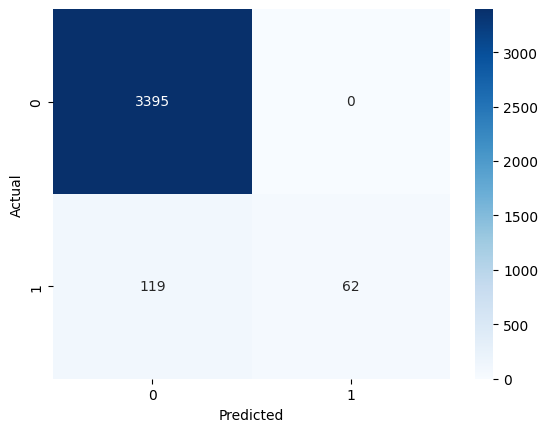

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3395
           1       1.00      0.34      0.51       181

    accuracy                           0.97      3576
   macro avg       0.98      0.67      0.75      3576
weighted avg       0.97      0.97      0.96      3576



In [48]:
# Make predictions on test set
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Precision, Recall, F1-score
print(classification_report(y_test, y_pred))

### Check Class Distribution
Identify imbalance in the dataset; fake jobs are much fewer than real jobs.

In [49]:
# Check class distribution
df['fraudulent'].value_counts()

,count
fraudulent,
0,17014
1,866


### Install Imbalanced-learn
Required to perform oversampling of the minority class.

In [50]:
# Install imbalanced-learn (only needed once per session)
!pip install imbalanced-learn

### Handle Imbalance (Oversampling)
Oversample the minority class to improve detection of fake jobs (increase recall).

In [51]:
from imblearn.over_sampling import RandomOverSampler

# Oversample minority class
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X, y)

print("After oversampling:", y_res.value_counts())

After oversampling: fraudulent
0    17014
1    17014
Name: count, dtype: int64


### Train Model on Balanced Data
Retrain and evaluate model on balanced dataset. Check improvements in recall, precision, and overall performance.

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      3396
           1       0.98      1.00      0.99      3410

    accuracy                           0.99      6806
   macro avg       0.99      0.99      0.99      6806
weighted avg       0.99      0.99      0.99      6806



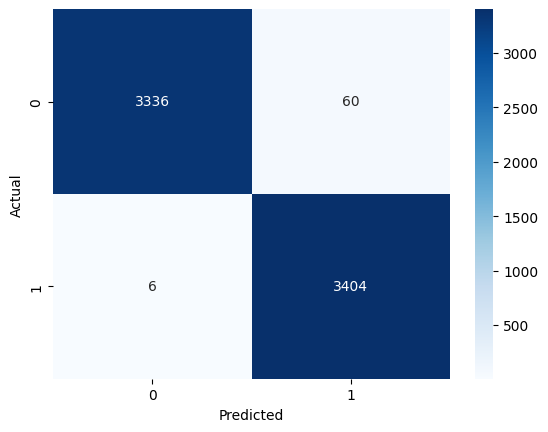

In [52]:
# Split balanced data
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

# Retrain Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Model Comparison

In this step, we train a second machine learning model (Multinomial Naive Bayes)
to compare performance with Logistic Regression.

This helps us understand which algorithm works better for text classification.

Naive Bayes Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.93      0.95      3396
           1       0.94      0.98      0.96      3410

    accuracy                           0.96      6806
   macro avg       0.96      0.96      0.96      6806
weighted avg       0.96      0.96      0.96      6806



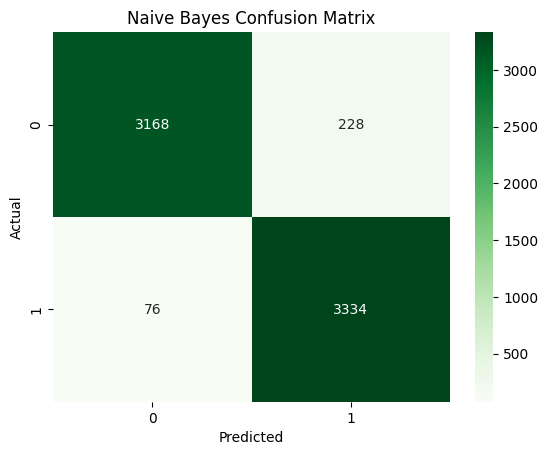

In [53]:
# Import Naive Bayes model
from sklearn.naive_bayes import MultinomialNB

# Train Naive Bayes on balanced data
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Make predictions
nb_pred = nb_model.predict(X_test)

# Evaluate performance
from sklearn.metrics import classification_report, confusion_matrix

print("Naive Bayes Classification Report:\n")
print(classification_report(y_test, nb_pred))

# Confusion Matrix
cm_nb = confusion_matrix(y_test, nb_pred)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Naive Bayes Confusion Matrix")
plt.show()

## Feature Importance Analysis

In this step, we analyze which words contribute most to predicting fake and real job postings.
This helps us understand how the model makes decisions.

In [54]:
# Get feature names (words)
feature_names = vectorizer.get_feature_names_out()

# Get model coefficients
coefficients = model.coef_[0]

# Create DataFrame of words with importance
import pandas as pd

importance_df = pd.DataFrame({
    'word': feature_names,
    'coefficient': coefficients
})

# Sort words by importance
top_fake_words = importance_df.sort_values(by='coefficient', ascending=False).head(15)
top_real_words = importance_df.sort_values(by='coefficient').head(15)

print("Top words indicating FAKE jobs:\n")
print(top_fake_words)

print("\nTop words indicating REAL jobs:\n")
print(top_real_words)

Top words indicating FAKE jobs:

                word  coefficient
47976           link     4.894635
26985           earn     4.737983
53275          money     4.445338
29520          entry     4.438207
15318          clerk     4.307695
56755       offshore     4.152947
28933    engineering     3.764838
13623           cash     3.660498
94683          wages     3.650112
74304          rohan     3.544690
7842       assistant     3.529018
83321         subsea     3.462707
55792       novation     3.442320
15315       clerical     3.436464
60898  perioperative     3.242329

Top words indicating REAL jobs:

              word  coefficient
95153      website    -4.019684
85650         team    -3.866983
29113      english    -3.834022
37791      growing    -3.346131
15355       client    -3.248769
97067         year    -3.247770
48205           ll    -3.210067
30605    essential    -3.029559
15419      clients    -2.918404
74032        right    -2.847588
9453         based    -2.774830
34090

### Feature Importance Insights

The model identifies words such as "earn", "money", "cash", and "link" as strong indicators of fraudulent job postings.
These terms are commonly associated with scam-like language.

In contrast, words like "team", "client", "growing", and "digital" are associated with legitimate job postings,
reflecting professional and organizational contexts.

This analysis improves model interpretability and demonstrates how textual patterns influence classification decisions.

## Custom Job Prediction Function

In this step, we create a function that allows us to input a new job posting
and predict whether it is fraudulent or legitimate.

This makes the model practical and ready for real-world usage.

In [55]:
# Function to predict new job posting

def predict_job(text_input):

    # Convert text into TF-IDF features
    text_vector = vectorizer.transform([text_input])

    # Predict
    prediction = model.predict(text_vector)[0]

    # Probability
    probability = model.predict_proba(text_vector)[0]

    if prediction == 1:
        print("🚨 This job posting is predicted as FAKE")
    else:
        print("✅ This job posting is predicted as REAL")

    print(f"Confidence: {max(probability)*100:.2f}%")

In [56]:
# Example 1 - Likely Fake
fake_example = "Earn money quickly from home. No experience required. Click this link now!"
predict_job(fake_example)

🚨 This job posting is predicted as FAKE
Confidence: 98.87%


In [57]:
# Example 2 - Likely Real
real_example = "We are looking for a software engineer to join our growing team. Strong communication skills required."
predict_job(real_example)

✅ This job posting is predicted as REAL
Confidence: 98.62%


## Day 7 — Custom Job Prediction

In this step, we create a function to input a job description and predict whether it is fake or real using the trained model.

In [58]:
# Function to predict new job posting

def predict_job(text_input):

    # Convert text into TF-IDF features
    text_vector = vectorizer.transform([text_input])

    # Predict class (0 = real, 1 = fake)
    prediction = model.predict(text_vector)[0]

    # Get probability
    probability = model.predict_proba(text_vector)[0]

    if prediction == 1:
        print("🚨 This job posting is predicted as FAKE")
    else:
        print("✅ This job posting is predicted as REAL")

    print(f"Confidence: {max(probability)*100:.2f}%")

In [59]:
# Fake example
fake_example = "Earn money quickly from home. No experience required. Click this link now!"
predict_job(fake_example)

🚨 This job posting is predicted as FAKE
Confidence: 98.87%


In [60]:
# Real example
real_example = "We are hiring a software engineer to join our growing team. Strong communication skills required."
predict_job(real_example)

✅ This job posting is predicted as REAL
Confidence: 95.20%


## Day 8 — Saving the Model

In this step, we save the trained machine learning model and TF-IDF vectorizer.
This allows us to reuse the model later without retraining.

In [61]:
# Save model and vectorizer
import pickle

# Save model
with open('/content/drive/MyDrive/Fake_Job_Project/model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save vectorizer
with open('/content/drive/MyDrive/Fake_Job_Project/vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [62]:
# Load model and vectorizer

with open('/content/drive/MyDrive/Fake_Job_Project/model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('/content/drive/MyDrive/Fake_Job_Project/vectorizer.pkl', 'rb') as f:
    loaded_vectorizer = pickle.load(f)

print("Loaded successfully!")

Loaded successfully!


In [63]:
# Test loaded model

text = "Earn money quickly from home without experience"
text_vector = loaded_vectorizer.transform([text])

prediction = loaded_model.predict(text_vector)

print("Prediction:", prediction[0])

Prediction: 1


## Final Results and Conclusion

In this project, a machine learning model was developed to detect fraudulent job postings using Natural Language Processing (NLP) techniques.

The text data was processed using TF-IDF vectorization, and multiple models were trained and evaluated. Logistic Regression performed the best, achieving high accuracy and strong performance in detecting fake job postings after handling class imbalance.

The model was further enhanced by analyzing important features and building a custom prediction function, making it practical for real-world usage.

## Future Improvements

• Improve text preprocessing using advanced NLP techniques  
• Try more advanced models like Random Forest or Deep Learning  
• Build a web application using Streamlit for user interaction  
• Deploy the model for real-time job fraud detection  

## Project Workflow

1. Data Loading and Exploration  
2. Text Preprocessing and Feature Engineering  
3. Model Training (Logistic Regression, Naive Bayes)  
4. Model Evaluation (Accuracy, Precision, Recall, F1-score)  
5. Handling Class Imbalance (Oversampling)  
6. Feature Importance Analysis  
7. Custom Prediction Function  
8. Model Saving and Reusability  

## Building a Streamlit App

In this step, we create a simple web application using Streamlit that allows users to input job descriptions and get predictions on whether the job posting is fake or real.

In [64]:
# Install Streamlit
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 120.6 MB/s eta 0:00:00


In [65]:
# App Code


%%writefile app.py

import streamlit as st
import pickle

# Load model and vectorizer
with open('/content/drive/MyDrive/Fake_Job_Project/model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('/content/drive/MyDrive/Fake_Job_Project/vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

# Title
st.title("Fake Job Posting Detection")

st.write("Enter a job description below to check if it is fake or real.")

# Input box
user_input = st.text_area("Job Description")

# Button
if st.button("Predict"):
    if user_input:
        text_vector = vectorizer.transform([user_input])
        prediction = model.predict(text_vector)[0]
        probability = model.predict_proba(text_vector)[0]

        if prediction == 1:
            st.error("🚨 This job posting is FAKE")
        else:
            st.success("✅ This job posting is REAL")

        st.write(f"Confidence: {max(probability)*100:.2f}%")
    else:
        st.warning("Please enter a job description")

Writing app.py


In [ ]:
# Run App
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.186.41.6:8501

